# < 사인 함수 예측하기 >

- 한번 정리하고, 백지에서 복기해봐라.
## 0. 목차
- 1.딥러닝 모델의 가중치
- 2.3차 다항식 모델 정의하기
- 3.3차 다항식 모델 학습하기
- 4.자동 미분(Auto-Grad)
- 5.파이토치 모듈 사용하기
- 6.최적화 함수
  

## 1. 딥러닝 모델의 가중치
### 딥러닝 학습 과정
- 데이터 준비
- 모델 정의
- 순전파 (반복에서 돌아옴)
- 오차계산 및 역전파
- 가중치 업데이트
- 반복
- 학습 종료



## 2. 3차 다항식 모델 정의하기
- 사인 함수를 3차 다항식 모델로 표현해보겠다. (신경망을 써서)

In [1]:
import math
import torch


x=torch.linspace(-math.pi, math.pi,1000) # -pi, +pi 범위를 1000등분 한다.
y=torch.sin(x)

# 3차 다항식 모델
# ax^3 + bx^2 + cx + d= 0, a !=0

# 초기화
a= torch.randn(()) # 정규분포를 따르는 size 크기만큼의 랜덤 값을 반환하는 함수
b= torch.randn(())
c= torch.randn(())
d= torch.randn(())

# 모델
y_random = (a*x**3)+(b*x**2) + (c*x)+d


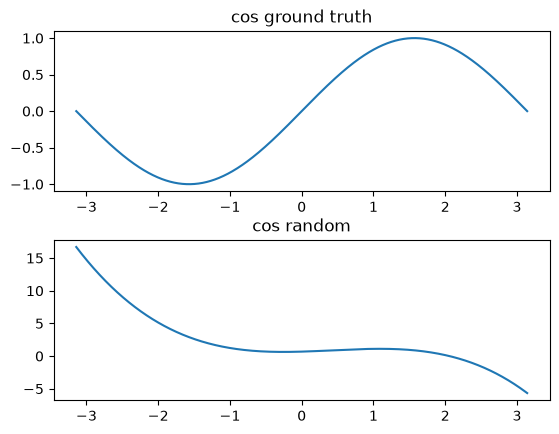

In [2]:
import matplotlib.pyplot as plt # 그래프 표시하는 부분

plt.subplot(2,1,1)
plt.subplots_adjust(hspace=0.3) # subplot의 상하 간격을 지정한다.
plt.title("cos ground truth")
plt.plot(x,y)

plt.subplot(2,1,2)
plt.title("cos random")
plt.plot(x,y_random)

plt.show()




## 3.3차 다항식 모델 학습하기


In [3]:
# 하이퍼 파라미터
learning_rate = 1e-6

# 데이터셋
x=torch.linspace(-math.pi, math.pi, 1000)
y=torch.sin(x)

# 모델 가중치 초기화
a = torch.randn(())
b = torch.randn(())
c = torch.randn(())
d = torch.randn(())

for epoch in range(2000): # 노가다 방식
    #순전파
    y_pred = (a*x**3) + (b*x**2) + (c*x) + d

    #오차 계산 (MSE)
    loss = (y_pred - y).pow(2).sum().item() # 평균 제곱 오차 

    #백워드, 미분값(gradient) 계산
    grad_y_pred = 2.0 * (y_pred - y)
    grad_a = (grad_y_pred*x **3).sum()
    grad_b = (grad_y_pred*x **2).sum()
    grad_c = (grad_y_pred*x).sum()
    grad_d = (grad_y_pred).sum()

    #가중치 업데이트
    a -= learning_rate * grad_a
    b -= learning_rate * grad_b
    c -= learning_rate * grad_c
    d -= learning_rate * grad_d

    #출력
    if epoch %100 ==0:
        print("epcoh:",epoch,"loss:",loss)
    


epcoh: 0 loss: 2524.50927734375
epcoh: 100 loss: 624.9287109375
epcoh: 200 loss: 524.0103149414062
epcoh: 300 loss: 439.58856201171875
epcoh: 400 loss: 368.9314270019531
epcoh: 500 loss: 309.78564453125
epcoh: 600 loss: 260.26910400390625
epcoh: 700 loss: 218.80801391601562
epcoh: 800 loss: 184.08697509765625
epcoh: 900 loss: 155.00682067871094
epcoh: 1000 loss: 130.64776611328125
epcoh: 1100 loss: 110.24071502685547
epcoh: 1200 loss: 93.14248657226562
epcoh: 1300 loss: 78.81478881835938
epcoh: 1400 loss: 66.80730438232422
epcoh: 1500 loss: 56.74312973022461
epcoh: 1600 loss: 48.30687713623047
epcoh: 1700 loss: 41.23439407348633
epcoh: 1800 loss: 35.30461502075195
epcoh: 1900 loss: 30.33241081237793


In [4]:
# 학습된 가중치를 확인해 보자.
print(a,b,c,d)


tensor(-0.0853) tensor(-0.0366) tensor(0.8002) tensor(0.2124)


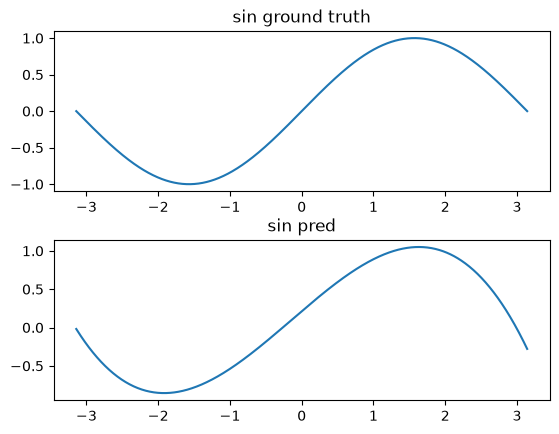

In [5]:
#그래프로 관측해보자
plt.subplot(2,1,1)
plt.subplots_adjust(hspace=0.3) # subplot의 상하 간격을 지정한다.
plt.title("sin ground truth")
plt.plot(x,y)

plt.subplot(2,1,2)
plt.title("sin pred")
plt.plot(x,y_pred)

plt.show()


## 4.자동 미분(Auto-Grad)
- 앞선 예제에서는 가중치를 업데이트 할 때 미분값을 직접 계산해서 업데이트를 했다.
- 수천 개의 가중치 미분값을 수동으로 계산하여 모델에 업데이트 하는 것은 불가능하므로...
- 파이토치에서 제공하는 자동 미분 기능을 사용.
- torch.no_grad()
- torch.Tensor.backward()
- torch.Tensor.clone()
- torch.Tensor.detach()
- torch.Tensor.numpy()
- 

In [6]:
# 하이퍼파라미터
learning_rate = 1e-6

# 데이터셋
x = torch.linspace(-math.pi, math.pi, 1000)
y = torch.sin(x)

# 모델 가중치 초기화
a = torch.tensor(torch.randn(()), requires_grad= True)
b = torch.tensor(torch.randn(()), requires_grad= True)
c = torch.tensor(torch.randn(()), requires_grad= True)
d = torch.tensor(torch.randn(()), requires_grad= True)


for epoch in range(2000):
    #순전파
    y_pred = (a*x**3) + (b*x**2) + (c*x) +d

    #오차 계산(MSE)
    loss = (y_pred - y).pow(2).sum()

    #백워드
    loss.backward()
    
    #가중치 업데이트

    
    with torch.no_grad(): 
        # with 구문은 특정 작업의 시작과 끝에서 실행 환경을 자동으로 설정 및 해제해 주는 파이썬의 표준 구문입니다.
        #계산 그래프에서 아래 업데이트 내역은 기록하지 말아야 연산 역추적이 가능하다.
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        c -= learning_rate * c.grad
        d -= learning_rate * d.grad

        #기울기 초기화
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

        # 출력
        if epoch %100 == 0 :
            print("epoch:", epoch, "loss : " ,loss.item())
            
        

epoch: 0 loss :  17866.40625
epoch: 100 loss :  645.2388305664062
epoch: 200 loss :  538.2696533203125


/tmp/ipykernel_23224/1667371137.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  a = torch.tensor(torch.randn(()), requires_grad= True)
/tmp/ipykernel_23224/1667371137.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(torch.randn(()), requires_grad= True)
/tmp/ipykernel_23224/1667371137.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c = torch.tensor(torch.randn(()), requires_grad= True)
/tmp/ipykernel_23224/1667371137.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.cl

epoch: 300 loss :  449.2692565917969
epoch: 400 loss :  375.19305419921875
epoch: 500 loss :  313.5230712890625
epoch: 600 loss :  262.1685485839844
epoch: 700 loss :  219.39385986328125
epoch: 800 loss :  183.75717163085938
epoch: 900 loss :  154.06048583984375
epoch: 1000 loss :  129.3076629638672
epoch: 1100 loss :  108.67110443115234
epoch: 1200 loss :  91.4624252319336
epoch: 1300 loss :  77.1090087890625
epoch: 1400 loss :  65.13460540771484
epoch: 1500 loss :  55.14268493652344
epoch: 1600 loss :  46.80327224731445
epoch: 1700 loss :  39.841644287109375
epoch: 1800 loss :  34.029014587402344
epoch: 1900 loss :  29.174781799316406


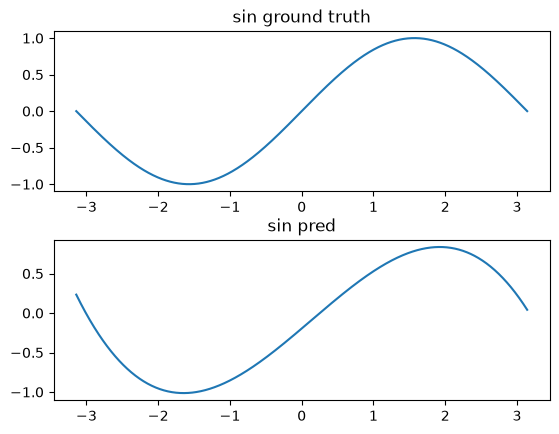

In [7]:
#마지막으로 계산된 모델의 예측값을 numpy 형태로 변경한다.
y_pred = y_pred.clone().detach().numpy()

plt.subplot(2,1,1)
plt.subplots_adjust(hspace=0.3) # subplot의 상하 간격을 지정한다.
plt.title("sin ground truth")
plt.plot(x,y)

plt.subplot(2,1,2)
plt.title("sin pred")
plt.plot(x,y_pred)

plt.show()



## 5.파이토치 모듈 사용하기
- 파이토치 모델은 nn.Module을 상속받는 클래스 형태로 정의하는 스타일을 권장한다.
- 3차 다항식 모델을 nn.Module을 이용한 모델로 만들어 보겠다.
- 모델은 크게 두 파트로 구분되어 있다.
  - 1.생성자에서 모델에서 사용하는 가중치를 초기화 한다.
  - 2.forward 함수로 순전파를 구현합니다.
  

In [8]:
import torch
import torch.nn as nn

class LegendrePolynomial3(nn.Module):
    
    def __init__(self) : 
        super().__init__()
        self.a = nn.Parameter(torch.randn(()))
        self.b = nn.Parameter(torch.randn(()))
        self.c = nn.Parameter(torch.randn(()))
        self.d = nn.Parameter(torch.randn(()))

    def forward(self, x):
        return (self.a * x **3) + (self.b *x **2) + (self.c * x) + self.d


# 하이퍼 파라미터
learning_rate = 1e-6

# 데이터셋
x = torch.linspace(-math.pi, math.pi, 1000)
y = torch.sin(x)

# 모델 초기화
model = LegendrePolynomial3()

for epoch in range(2000):
    # 순전파
    y_pred = model(x)

    # 오차 계산(MSE)
    loss = nn.MSELoss(reduction = 'sum')(y_pred,y) # SSE, Sum Square Error

    # 백워드
    loss.backward()

    # 가중치 업데이트
    with torch.no_grad() :
        model.a -= learning_rate * model.a.grad
        model.b -= learning_rate * model.b.grad
        model.c -= learning_rate * model.c.grad
        model.d -= learning_rate * model.d.grad

        model.a.grad = None
        model.b.grad = None
        model.c.grad = None
        model.d.grad = None

    # 출력
    if epoch % 100 == 0 :
        print("epoch : " , epoch, "loss:",loss.item())




epoch :  0 loss: 4711.59765625
epoch :  100 loss: 589.6973876953125
epoch :  200 loss: 479.89263916015625
epoch :  300 loss: 391.0216369628906
epoch :  400 loss: 318.7619323730469
epoch :  500 loss: 260.008544921875
epoch :  600 loss: 212.23696899414062
epoch :  700 loss: 173.39447021484375
epoch :  800 loss: 141.81216430664062
epoch :  900 loss: 116.13300323486328
epoch :  1000 loss: 95.25363159179688
epoch :  1100 loss: 78.27694702148438
epoch :  1200 loss: 64.47344207763672
epoch :  1300 loss: 53.25003433227539
epoch :  1400 loss: 44.12429428100586
epoch :  1500 loss: 36.70433044433594
epoch :  1600 loss: 30.67122459411621
epoch :  1700 loss: 25.76580047607422
epoch :  1800 loss: 21.77728271484375
epoch :  1900 loss: 18.534273147583008


- 이번 예제에서 사용하는 손실 함수는 합 제곱 오차(SSE)이다.
- 평균 오차 제곱 손실 함수에서 reduction 인자를 sumd으로 해주면 된다.


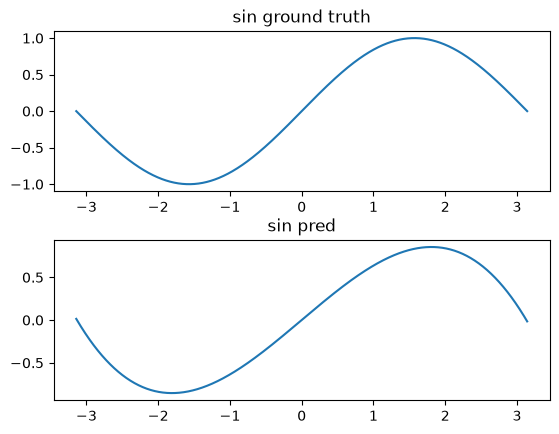

In [9]:
x = x.squeeze()
y_pred = model(x).clone().detach().squeeze().numpy()
y=y.squeeze()

plt.subplot(2,1,1)
plt.subplots_adjust(hspace=0.3) # subplot의 상하 간격을 지정한다.
plt.title("sin ground truth")
plt.plot(x,y)

plt.subplot(2,1,2)
plt.title("sin pred")
plt.plot(x,y_pred)

plt.show()


## 6.최적화 함수
- 파이토치에는 가중치 업데이트를 도와주는 최적화 함수가 있다.
- 최적화 함수는 계산된 미분값을 업데이트 하는 경우 다양한 방식에 따라 변경 된다.
- 이번 예제에서는 SGD를 사용한다.


In [10]:
# 하이퍼파라미터
learning_rate = 1e-6

# 데이터셋
x=torch.linspace(-math.pi, math.pi, 1000)
y=torch.sin(x)

# 모델 초기화
model = LegendrePolynomial3()

# 손실 함수
criterion =nn.MSELoss(reduction = 'sum')

# 최적화 함수 
print(list(model.parameters()))
optimizer = torch.optim.SGD(params =model.parameters(), lr=learning_rate)

for epoch in range(2000):
    #미분값 초기화
    optimizer.zero_grad()

    #순전파
    y_pred = model(x)

    #오차 계산 
    loss = criterion(y_pred, y)

    #백워드
    loss.backward()

    #가중치 업데이트
    optimizer.step()

    #출력
    if epoch % 100 == 0:
        print("epoch : " , epoch, "loss:",loss.item())


[Parameter containing:
tensor(-0.4894, requires_grad=True), Parameter containing:
tensor(-0.4163, requires_grad=True), Parameter containing:
tensor(2.0500, requires_grad=True), Parameter containing:
tensor(-0.3662, requires_grad=True)]
epoch :  0 loss: 12417.814453125
epoch :  100 loss: 679.9176025390625
epoch :  200 loss: 553.5361328125
epoch :  300 loss: 451.6248779296875
epoch :  400 loss: 368.64764404296875
epoch :  500 loss: 301.0828552246094
epoch :  600 loss: 246.06565856933594
epoch :  700 loss: 201.26344299316406
epoch :  800 loss: 164.7777099609375
epoch :  900 loss: 135.06304931640625
epoch :  1000 loss: 110.86172485351562
epoch :  1100 loss: 91.14952087402344
epoch :  1200 loss: 75.09297180175781
epoch :  1300 loss: 62.01326370239258
epoch :  1400 loss: 51.35798645019531
epoch :  1500 loss: 42.67716979980469
epoch :  1600 loss: 35.60440444946289
epoch :  1700 loss: 29.841278076171875
epoch :  1800 loss: 25.145267486572266
epoch :  1900 loss: 21.31844711303711


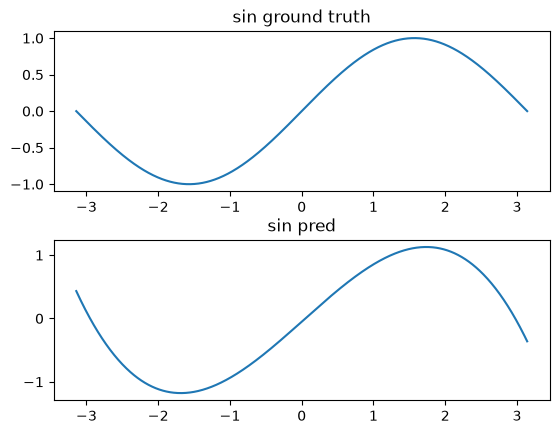

In [11]:
x = x.squeeze()
y_pred = model(x).clone().detach().squeeze().numpy()
y=y.squeeze()

plt.subplot(2,1,1)
plt.subplots_adjust(hspace=0.3) # subplot의 상하 간격을 지정한다.
plt.title("sin ground truth")
plt.plot(x,y)

plt.subplot(2,1,2)
plt.title("sin pred")
plt.plot(x,y_pred)

plt.show()